## IMPORT LIBRARIES

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, confusion_matrix, accuracy_score)
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report

In [14]:
df = pd.read_csv(r"D:\DOWNLOADS\Smart Factory Machine Predictor\smart factory machinery data_set.csv")
print(df.head(5))

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [16]:
df = df.drop(["UDI", "Product ID"], axis = 1)

## SINGLE LINEAR REGRESSION

Linear Mean Squared Error: 2.1691240317336407
Intercept: 309.72569391219616
Coefficient: 0.00018221851258225778


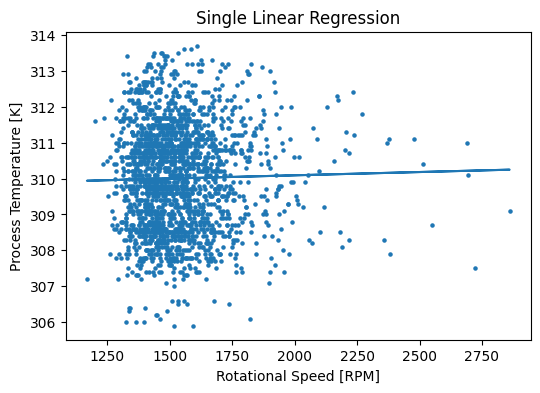

In [74]:
X = df[['Rotational speed [rpm]']]
y = df['Process temperature [K]']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Linear Mean Squared Error:", mse)
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

plt.figure(figsize=(6, 4))
plt.scatter(X_test, y_test, s= 5)
plt.plot(X_test, y_pred)
plt.xlabel("Rotational Speed [RPM]")
plt.ylabel("Process Temperature [K]")
plt.title("Single Linear Regression")
plt.show()

## MULTI LINEAR REGRESSION

In [43]:
X = df[[
    'Air temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]]

y = df['Process temperature [K]']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)
y_pred_multi = multi_model.predict(X_test)

mse_multi = mean_squared_error(y_test, y_pred_multi)
print("Multi Mean Squared Error:", mse_multi)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multi_model.coef_
})
print(coefficients)

new_machine = pd.DataFrame({
    'Air temperature [K]'   : [300],
    'Rotational speed [rpm]': [1500],
    'Torque [Nm]'           : [40],
    'Tool wear [min]'       : [10]
})
prediction = multi_model.predict(new_machine)
print("Predicted Process Temperature:", prediction)

Multi Mean Squared Error: 0.5298708765361675
                  Feature  Coefficient
0     Air temperature [K]     0.651688
1  Rotational speed [rpm]    -0.000099
2             Torque [Nm]    -0.002450
3         Tool wear [min]    -0.000066
Predicted Process Temperature: [310.00994336]


## SAVE AND LOAD MODEL

In [61]:
## PICKLE
with open("temperature_model.pkl", "wb") as file:
    pickle.dump(multi_model, file)
with open("temperature_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)
    
new_machine = pd.DataFrame({
    'Air temperature [K]'   : [300],
    'Rotational speed [rpm]': [1500],
    'Torque [Nm]'           : [40],
    'Tool wear [min]'       : [10]
})

prediction = loaded_model.predict(new_machine)
print("Predicted Temperature in pickle model:", prediction)

## JOBLIB
joblib.dump(multi_model, "temperature_model_joblib.pkl")
loaded_joblib_model = joblib.load("temperature_model_joblib.pkl")

prediction = loaded_joblib_model.predict(new_machine)
print("Predicted Temperature in joblib model:", prediction)

print("Loaded Model Coefficient:", loaded_model.coef_)
print("Loaded Model Intercept:", loaded_model.intercept_)

Predicted Temperature in pickle model: [310.00994336]
Predicted Temperature in joblib model: [310.00994336]
Loaded Model Coefficient: [ 6.51688239e-01 -9.91872755e-05 -2.44969676e-03 -6.58579419e-05]
Loaded Model Intercept: 114.75089892349041


## ONE HOT ENCODING

In [67]:
print(df['Type'].unique())
encoded_df = pd.get_dummies(
    df,
    columns=['Type'],
    drop_first=True
)
print(encoded_df.head())
print(encoded_df.info())
print(encoded_df.columns)

['M' 'L' 'H']
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  \
0         42.8                0                0    0    0    0    0    0   
1         46.3                3                0    0    0    0    0    0   
2         49.4                5                0    0    0    0    0    0   
3         39.5                7                0    0    0    0    0    0   
4         40.0                9                0    0    0    0    0    0   

   Type_L  Type_M  
0   False    True  
1    True   False  
2    True   

## TRAIN_TEST_SPLIT

Training Features Shape: (8000, 12)
Testing Features Shape: (2000, 12)
Training Target Shape: (8000,)
Testing Target Shape: (2000,)
Train-Test Split MSE: 0.5262766757748051
      Actual Temperature  Predicted Temperature
6252               310.3             310.537594
4684               311.8             312.536024
1731               307.9             308.876286
4742               311.3             312.201596
4521               310.4             311.581225
6340               309.9             310.353928
576                309.7             308.493816
5202               312.7             312.454304
6363               309.6             309.997093
439                308.3             308.294219


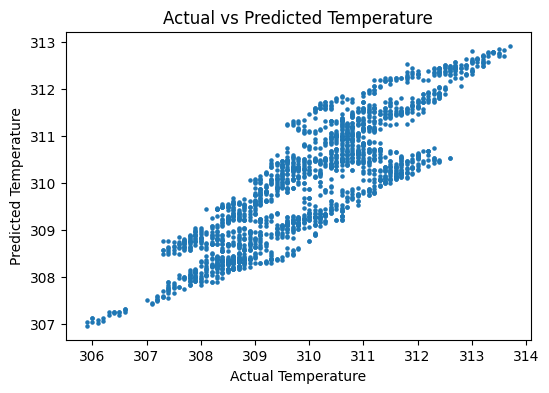

R² Score: 0.7573412252273155


In [75]:
X = encoded_df.drop('Process temperature [K]', axis=1)
y = encoded_df['Process temperature [K]']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

split_model = LinearRegression()
split_model.fit(X_train, y_train)
y_pred_split = split_model.predict(X_test)
split_mse = mean_squared_error(y_test, y_pred_split)
print("Train-Test Split MSE:", split_mse)

comparison = pd.DataFrame({
    'Actual Temperature': y_test,
    'Predicted Temperature': y_pred_split
})
print(comparison.head(10))

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_split, s = 5)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()

print("R² Score:", split_model.score(X_test, y_test))

## LOGISTIC REGRESSION

Accuracy: 0.974
Confusion Matrix: [[1930    9]
 [  43   18]]


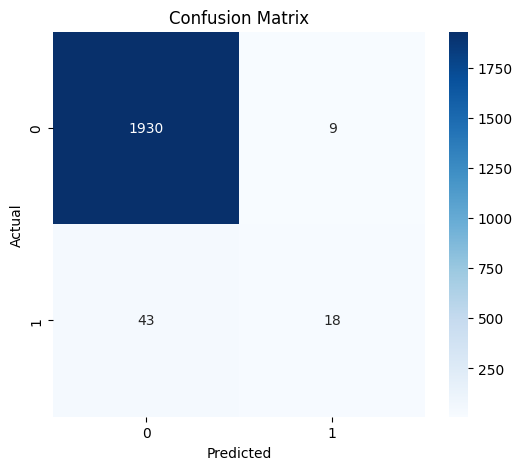

Predicted Machine Failure: [0]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.67      0.30      0.41        61

    accuracy                           0.97      2000
   macro avg       0.82      0.65      0.70      2000
weighted avg       0.97      0.97      0.97      2000



In [82]:
X = encoded_df.drop('Machine failure', axis=1)
y = encoded_df['Machine failure']
X = encoded_df.drop([
    'Machine failure',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
], axis=1)
y = encoded_df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_log)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:", cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

new_machine = pd.DataFrame({
    'Air temperature [K]': [298.5],
    'Process temperature [K]': [310],
    'Rotational speed [rpm]': [1500],
    'Torque [Nm]': [40],
    'Tool wear [min]': [10],
    'Type_L': [0],
    'Type_M': [1]
})
prediction = log_model.predict(new_machine)
print("Predicted Machine Failure:", prediction)

print(classification_report(y_test, y_pred_log))